# 🎓 Student Performance Analysis
### Practical: Load External SQL Data in Google Colab + Pandas & NumPy Operations

**Dataset:** `students_data.sql` — 20 student records across 5 courses  
**Tools:** `sqlite3` · `pandas` · `numpy` · `matplotlib`

---


## 📦 Step 1 — Install Libraries & Import Modules

In [1]:
# Standard libraries (pre-installed in Colab)
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("✅ All libraries imported successfully!")
print(f"   pandas  version : {pd.__version__}")
print(f"   numpy   version : {np.__version__}")


✅ All libraries imported successfully!
   pandas  version : 2.2.2
   numpy   version : 2.0.2


## 📂 Step 2 — Upload the SQL File (External Data Loading)

Run the cell below. A **Choose Files** button will appear.  
Upload the `students_data.sql` file you downloaded alongside this notebook.


In [3]:
from google.colab import files

print("👆 Click 'Choose Files' and upload students_data.sql")
uploaded = files.upload()

sql_filename = list(uploaded.keys())[0]
print(f"\n✅ File uploaded: {sql_filename}  ({len(uploaded[sql_filename])} bytes)")


👆 Click 'Choose Files' and upload students_data.sql


Saving students_data.sql to students_data (1).sql

✅ File uploaded: students_data (1).sql  (2723 bytes)


## 🗄️ Step 3 — Create SQLite Database & Load SQL File

In [7]:
DB_PATH = "students.db"

# Ensure a fresh database for each run: delete if exists
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)
    print(f"🗑️ Removed existing database: {DB_PATH}")

# Connect (creates fresh DB in Colab's runtime)
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# Read and execute the uploaded SQL file
with open(sql_filename, "r") as f:
    sql_script = f.read()

conn.executescript(sql_script)
conn.commit()

# Verify table was created
cursor.execute("SELECT COUNT(*) FROM students")
row_count = cursor.fetchone()[0]
print(f"✅ Database ready!  Table 'students' has {row_count} rows.")

🗑️ Removed existing database: students.db
✅ Database ready!  Table 'students' has 20 rows.


## 🐼 Step 4 — Load SQL Table into a Pandas DataFrame

In [8]:
df = pd.read_sql_query("SELECT * FROM students", conn)

print("📋 Shape:", df.shape)
print("\n📌 Column Names:", df.columns.tolist())
print()
df.head(10)


📋 Shape: (20, 12)

📌 Column Names: ['student_id', 'name', 'age', 'gender', 'city', 'course', 'marks_math', 'marks_science', 'marks_english', 'attendance_percent', 'fee_paid', 'enrollment_date']



,student_id,name,age,gender,city,course,marks_math,marks_science,marks_english,attendance_percent,fee_paid,enrollment_date
0,1,Aarav Sharma,20,Male,Hyderabad,Computer Science,88.0,91.0,76.0,92.5,45000.0,2023-07-01
1,2,Priya Reddy,21,Female,Pune,Data Science,95.0,89.0,88.0,95.0,50000.0,2023-07-02
2,3,Rohit Kumar,19,Male,Delhi,Electronics,70.0,65.0,72.0,78.0,40000.0,2023-07-01
3,4,Sneha Nair,22,Female,Bangalore,Computer Science,82.0,88.0,90.0,88.5,45000.0,2023-07-03
4,5,Karan Mehta,20,Male,Mumbai,Mechanical,60.0,55.0,65.0,65.0,38000.0,2023-07-04
5,6,Divya Iyer,21,Female,Chennai,Data Science,91.0,94.0,85.0,97.0,50000.0,2023-07-02
6,7,Amit Singh,23,Male,Kolkata,Electrical,74.0,78.0,68.0,72.0,42000.0,2023-07-05
7,8,Pooja Verma,20,Female,Hyderabad,Computer Science,88.0,85.0,92.0,90.0,45000.0,2023-07-01
8,9,Nikhil Joshi,22,Male,Pune,Mechanical,55.0,60.0,58.0,60.5,38000.0,2023-07-06
9,10,Ananya Das,21,Female,Delhi,Electronics,79.0,83.0,77.0,84.0,40000.0,2023-07-03


## 🔍 Step 5 — Basic DataFrame Inspection

In [10]:
print("=" * 50)
print("📊 DataFrame Info")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("❓ Missing Values per Column")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("🔢 Data Types")
print("=" * 50)
print(df.dtypes)


📊 DataFrame Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          20 non-null     int64  
 1   name                20 non-null     object 
 2   age                 20 non-null     int64  
 3   gender              20 non-null     object 
 4   city                20 non-null     object 
 5   course              20 non-null     object 
 6   marks_math          20 non-null     float64
 7   marks_science       20 non-null     float64
 8   marks_english       20 non-null     float64
 9   attendance_percent  20 non-null     float64
 10  fee_paid            20 non-null     float64
 11  enrollment_date     20 non-null     object 
dtypes: float64(5), int64(2), object(5)
memory usage: 2.0+ KB

❓ Missing Values per Column
student_id            0
name                  0
age                   0
gender                0
city   

## 🛠️ Step 6 — Pandas Operations

In [12]:
# ── 6a. Add calculated column: Total Marks & Percentage ──────────────────────
df["total_marks"]   = df["marks_math"] + df["marks_science"] + df["marks_english"]
df["percentage"]    = (df["total_marks"] / 300 * 100).round(2)

# ── 6b. Grade assignment ──────────────────────────────────────────────────────
def assign_grade(pct):
    if pct >= 90: return "A+"
    elif pct >= 80: return "A"
    elif pct >= 70: return "B"
    elif pct >= 60: return "C"
    else: return "D"

df["grade"] = df["percentage"].apply(assign_grade)

print("✅ New columns added: total_marks, percentage, grade")
df[["name", "marks_math", "marks_science", "marks_english",
    "total_marks", "percentage", "grade"]].head(10)


✅ New columns added: total_marks, percentage, grade


,name,marks_math,marks_science,marks_english,total_marks,percentage,grade
0,Aarav Sharma,88.0,91.0,76.0,255.0,85.00,A
1,Priya Reddy,95.0,89.0,88.0,272.0,90.67,A+
2,Rohit Kumar,70.0,65.0,72.0,207.0,69.00,C
3,Sneha Nair,82.0,88.0,90.0,260.0,86.67,A
4,Karan Mehta,60.0,55.0,65.0,180.0,60.00,C
5,Divya Iyer,91.0,94.0,85.0,270.0,90.00,A+
6,Amit Singh,74.0,78.0,68.0,220.0,73.33,B
7,Pooja Verma,88.0,85.0,92.0,265.0,88.33,A
8,Nikhil Joshi,55.0,60.0,58.0,173.0,57.67,D
9,Ananya Das,79.0,83.0,77.0,239.0,79.67,B


In [13]:
# ── 6c. Filter: Students with percentage >= 85 ────────────────────────────────
top_students = df[df["percentage"] >= 85].sort_values("percentage", ascending=False)
print(f"🏆 Top Students (≥85%) — {len(top_students)} found:\n")
print(top_students[["name", "course", "city", "percentage", "grade"]].to_string(index=False))


🏆 Top Students (≥85%) — 10 found:

         name           course      city  percentage grade
 Ritu Chandra     Data Science   Chennai       94.33    A+
  Priya Reddy     Data Science      Pune       90.67    A+
  Shruti Bose      Electronics      Pune       90.00    A+
   Divya Iyer     Data Science   Chennai       90.00    A+
Rajesh Pillai     Data Science Bangalore       90.00    A+
  Pooja Verma Computer Science Hyderabad       88.33     A
   Sneha Nair Computer Science Bangalore       86.67     A
Vishal Tiwari     Data Science Hyderabad       85.33     A
 Aarav Sharma Computer Science Hyderabad       85.00     A
  Kavya Menon Computer Science    Mumbai       85.00     A


In [14]:
# ── 6d. GroupBy: Average percentage per Course ───────────────────────────────
course_avg = (df.groupby("course")["percentage"]
                .agg(["mean", "min", "max", "count"])
                .rename(columns={"mean":"Avg %","min":"Min %","max":"Max %","count":"Students"})
                .round(2)
                .sort_values("Avg %", ascending=False))

print("📚 Course-wise Performance:\n")
print(course_avg.to_string())


📚 Course-wise Performance:

                  Avg %  Min %  Max %  Students
course                                         
Data Science      90.07  85.33  94.33         5
Computer Science  83.33  71.67  88.33         5
Electronics       79.56  69.00  90.00         3
Electrical        73.89  68.33  80.00         3
Mechanical        64.59  57.67  77.00         4


In [16]:
# ── 6e. GroupBy: Gender-wise fee collection ───────────────────────────────────
gender_fee = df.groupby("gender")["fee_paid"].agg(["sum","mean","count"])
gender_fee.columns = ["Total Fee (₹)", "Avg Fee (₹)", "Students"]
gender_fee["Total Fee (₹)"] = gender_fee["Total Fee (₹)"].apply(lambda x: f"₹{x:,.0f}")
gender_fee["Avg Fee (₹)"]   = gender_fee["Avg Fee (₹)"].apply(lambda x: f"₹{x:,.0f}")
print("💰 Gender-wise Fee Analysis:\n")
print(gender_fee.to_string())


💰 Gender-wise Fee Analysis:

       Total Fee (₹) Avg Fee (₹)  Students
gender                                    
Female      ₹441,000     ₹44,100        10
Male        ₹432,000     ₹43,200        10


In [17]:
# ── 6f. Sorting & Selecting top 5 by attendance ──────────────────────────────
print("📅 Top 5 Students by Attendance:\n")
top_attend = df.nlargest(5, "attendance_percent")[["name","course","attendance_percent","percentage"]]
print(top_attend.to_string(index=False))

# ── 6g. Value counts: Grade distribution ─────────────────────────────────────
print("\n📊 Grade Distribution:")
print(df["grade"].value_counts().sort_index())


📅 Top 5 Students by Attendance:

         name       course  attendance_percent  percentage
 Ritu Chandra Data Science                98.0       94.33
   Divya Iyer Data Science                97.0       90.00
  Priya Reddy Data Science                95.0       90.67
  Shruti Bose  Electronics                94.0       90.00
Rajesh Pillai Data Science                93.5       90.00

📊 Grade Distribution:
grade
A     6
A+    5
B     4
C     4
D     1
Name: count, dtype: int64


## 🔢 Step 7 — NumPy Operations

In [18]:
# Convert marks columns to NumPy arrays
math_arr    = np.array(df["marks_math"])
sci_arr     = np.array(df["marks_science"])
eng_arr     = np.array(df["marks_english"])
attend_arr  = np.array(df["attendance_percent"])
pct_arr     = np.array(df["percentage"])

print("=" * 55)
print("📐 NumPy Statistical Analysis — Marks & Attendance")
print("=" * 55)

for label, arr in [("Math", math_arr), ("Science", sci_arr),
                   ("English", eng_arr), ("Attendance %", attend_arr),
                   ("Overall %", pct_arr)]:
    print(f"\n  {label}:")
    print(f"    Mean     : {np.mean(arr):.2f}")
    print(f"    Median   : {np.median(arr):.2f}")
    print(f"    Std Dev  : {np.std(arr):.2f}")
    print(f"    Variance : {np.var(arr):.2f}")
    print(f"    Min/Max  : {np.min(arr):.1f} / {np.max(arr):.1f}")


📐 NumPy Statistical Analysis — Marks & Attendance

  Math:
    Mean     : 79.60
    Median   : 81.00
    Std Dev  : 11.68
    Variance : 136.44
    Min/Max  : 55.0 / 96.0

  Science:
    Mean     : 79.35
    Median   : 82.50
    Std Dev  : 12.26
    Variance : 150.33
    Min/Max  : 55.0 / 95.0

  English:
    Mean     : 78.90
    Median   : 79.00
    Std Dev  : 9.88
    Variance : 97.59
    Min/Max  : 58.0 / 92.0

  Attendance %:
    Mean     : 83.42
    Median   : 86.75
    Std Dev  : 11.19
    Variance : 125.13
    Min/Max  : 60.5 / 98.0

  Overall %:
    Mean     : 79.28
    Median   : 82.50
    Std Dev  : 10.83
    Variance : 117.33
    Min/Max  : 57.7 / 94.3


In [19]:
# ── 7b. Correlation matrix using NumPy ───────────────────────────────────────
marks_matrix = np.column_stack([math_arr, sci_arr, eng_arr, pct_arr])
corr_matrix  = np.corrcoef(marks_matrix.T)

labels = ["Math", "Science", "English", "Overall %"]
print("🔗 Correlation Matrix (NumPy):\n")
header = f"{'':>12}" + "".join(f"{l:>12}" for l in labels)
print(header)
for i, row_label in enumerate(labels):
    row = f"{row_label:>12}" + "".join(f"{corr_matrix[i,j]:>12.4f}" for j in range(4))
    print(row)


🔗 Correlation Matrix (NumPy):

                    Math     Science     English   Overall %
        Math      1.0000      0.9429      0.9001      0.9888
     Science      0.9429      1.0000      0.8007      0.9596
     English      0.9001      0.8007      1.0000      0.9296
   Overall %      0.9888      0.9596      0.9296      1.0000


In [20]:
# ── 7c. Percentile analysis ───────────────────────────────────────────────────
print("📈 Percentile Analysis — Overall Percentage:")
for p in [25, 50, 75, 90]:
    print(f"   {p}th percentile : {np.percentile(pct_arr, p):.2f}%")

# ── 7d. Boolean masking ───────────────────────────────────────────────────────
above_avg_mask = pct_arr > np.mean(pct_arr)
print(f"\n✅ Students above class average ({np.mean(pct_arr):.2f}%): {np.sum(above_avg_mask)}")
print(f"❌ Students below class average              : {np.sum(~above_avg_mask)}")

# ── 7e. Normalize attendance (0-1) ───────────────────────────────────────────
norm_attend = (attend_arr - attend_arr.min()) / (attend_arr.max() - attend_arr.min())
df["attendance_normalized"] = np.round(norm_attend, 4)
print(f"\n📏 Normalized Attendance (0–1):")
print(f"   Min: {norm_attend.min():.4f}  |  Max: {norm_attend.max():.4f}  |  Mean: {norm_attend.mean():.4f}")


📈 Percentile Analysis — Overall Percentage:
   25th percentile : 71.00%
   50th percentile : 82.50%
   75th percentile : 88.75%
   90th percentile : 90.07%

✅ Students above class average (79.28%): 12
❌ Students below class average              : 8

📏 Normalized Attendance (0–1):
   Min: 0.0000  |  Max: 1.0000  |  Mean: 0.6113


## 📊 Step 8 — Visualizations

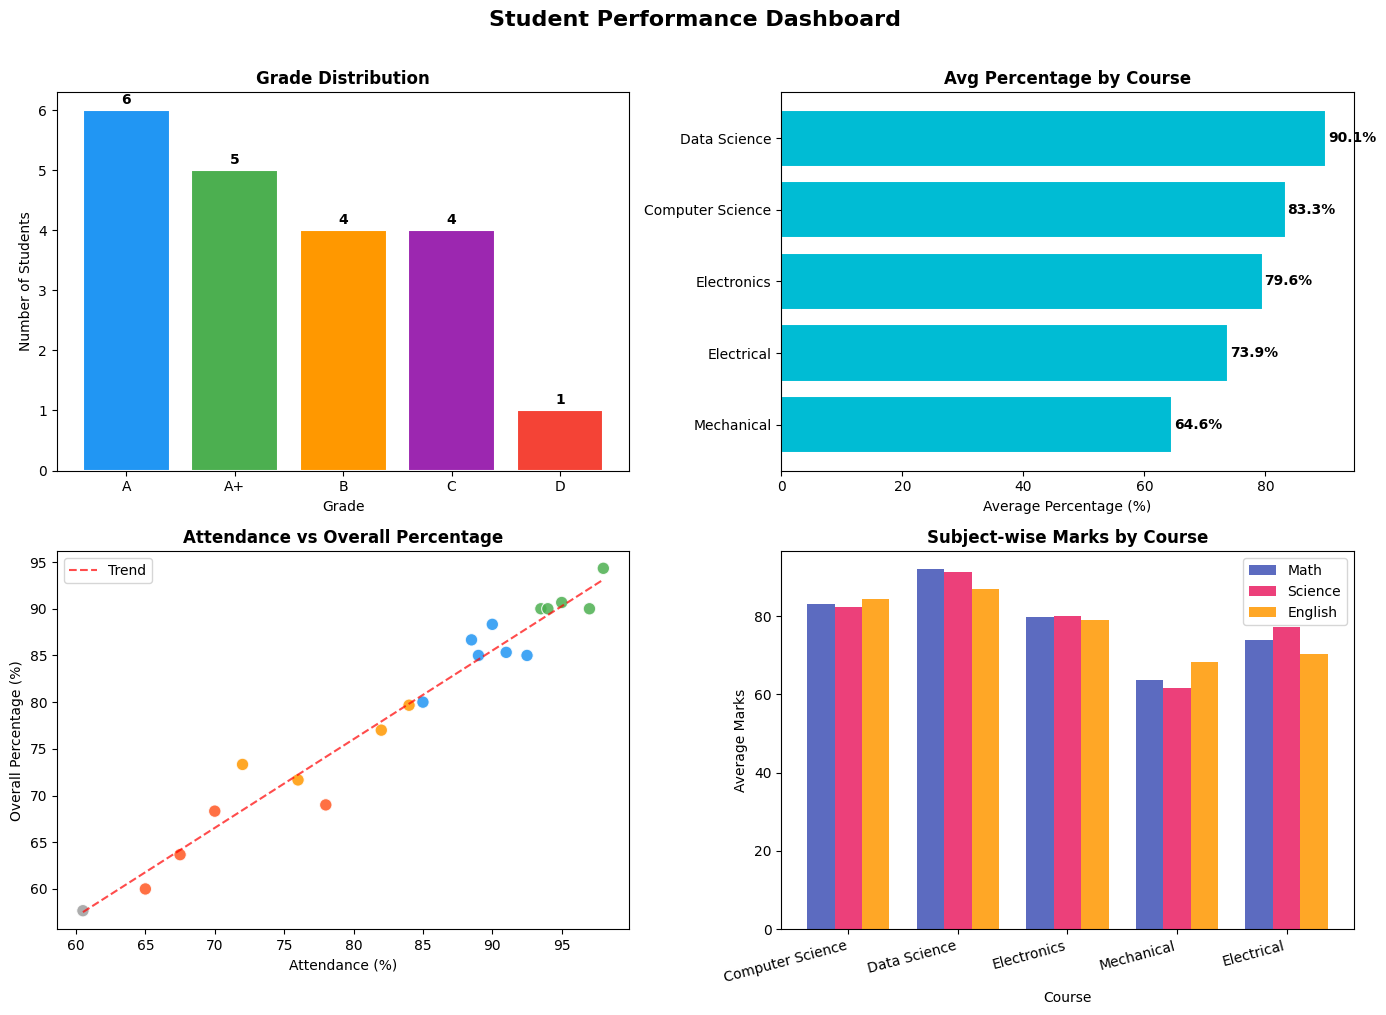

📸 Dashboard saved as dashboard.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Student Performance Dashboard", fontsize=16, fontweight="bold", y=1.01)

# ── Plot 1: Grade Distribution (Bar) ─────────────────────────────────────────
grade_counts = df["grade"].value_counts().sort_index()
colors = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336"]
axes[0,0].bar(grade_counts.index, grade_counts.values,
              color=colors[:len(grade_counts)], edgecolor="white", linewidth=1.5)
axes[0,0].set_title("Grade Distribution", fontweight="bold")
axes[0,0].set_xlabel("Grade"); axes[0,0].set_ylabel("Number of Students")
for i, v in enumerate(grade_counts.values):
    axes[0,0].text(i, v + 0.1, str(v), ha="center", fontweight="bold")

# ── Plot 2: Avg Percentage by Course (Horizontal Bar) ────────────────────────
course_pct = df.groupby("course")["percentage"].mean().sort_values()
axes[0,1].barh(course_pct.index, course_pct.values,
               color="#00BCD4", edgecolor="white", linewidth=1.5)
axes[0,1].set_title("Avg Percentage by Course", fontweight="bold")
axes[0,1].set_xlabel("Average Percentage (%)")
for i, v in enumerate(course_pct.values):
    axes[0,1].text(v + 0.3, i, f"{v:.1f}%", va="center", fontweight="bold")

# ── Plot 3: Attendance vs Percentage (Scatter) ────────────────────────────────
scatter_colors = df["grade"].map({"A+":"#4CAF50","A":"#2196F3","B":"#FF9800",
                                   "C":"#FF5722","D":"#9E9E9E"})
axes[1,0].scatter(df["attendance_percent"], df["percentage"],
                  c=scatter_colors, s=80, alpha=0.85, edgecolors="white", linewidth=0.8)
axes[1,0].set_title("Attendance vs Overall Percentage", fontweight="bold")
axes[1,0].set_xlabel("Attendance (%)"); axes[1,0].set_ylabel("Overall Percentage (%)")
# Trend line
z = np.polyfit(df["attendance_percent"], df["percentage"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["attendance_percent"].min(), df["attendance_percent"].max(), 100)
axes[1,0].plot(x_line, p(x_line), "r--", linewidth=1.5, alpha=0.7, label="Trend")
axes[1,0].legend()

# ── Plot 4: Subject-wise Average (Grouped Bar) ────────────────────────────────
courses  = df["course"].unique()
x        = np.arange(len(courses))
width    = 0.25
math_avg = [df[df["course"]==c]["marks_math"].mean()    for c in courses]
sci_avg  = [df[df["course"]==c]["marks_science"].mean() for c in courses]
eng_avg  = [df[df["course"]==c]["marks_english"].mean() for c in courses]

axes[1,1].bar(x - width, math_avg,    width, label="Math",    color="#3F51B5", alpha=0.85)
axes[1,1].bar(x,          sci_avg,    width, label="Science",  color="#E91E63", alpha=0.85)
axes[1,1].bar(x + width,  eng_avg,    width, label="English",  color="#FF9800", alpha=0.85)
axes[1,1].set_title("Subject-wise Marks by Course", fontweight="bold")
axes[1,1].set_xlabel("Course"); axes[1,1].set_ylabel("Average Marks")
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(courses, rotation=15, ha="right")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 Dashboard saved as dashboard.png")


## 🗃️ Step 9 — Advanced SQL Queries via Pandas

In [24]:
# Query 1: Students from Hyderabad
q1 = pd.read_sql_query(
    """SELECT name, course,
              ROUND((marks_math + marks_science + marks_english) / 300.0 * 100, 2) AS percentage
       FROM students WHERE city = 'Hyderabad' ORDER BY percentage DESC""",
    conn)
print("🏙️ Students from Hyderabad:")
print(q1.to_string(index=False))

# Query 2: Top scorer per course
q2 = pd.read_sql_query("""
    SELECT course,
           name,
           ROUND((marks_math + marks_science + marks_english) / 3.0, 2) AS avg_marks
    FROM   students
    WHERE  (marks_math + marks_science + marks_english) = (
               SELECT MAX(m.marks_math + m.marks_science + m.marks_english)
               FROM   students m WHERE m.course = students.course)
    ORDER  BY avg_marks DESC
""", conn)
print("\n🥇 Top Scorer per Course:")
print(q2.to_string(index=False))

🏙️ Students from Hyderabad:
         name           course  percentage
  Pooja Verma Computer Science       88.33
Vishal Tiwari     Data Science       85.33
 Aarav Sharma Computer Science       85.00

🥇 Top Scorer per Course:
          course          name  avg_marks
    Data Science  Ritu Chandra      94.33
     Electronics   Shruti Bose      90.00
Computer Science   Pooja Verma      88.33
      Electrical Deepak Shetty      80.00
      Mechanical   Meera Gupta      77.00


## 💾 Step 10 — Export Results to CSV

In [25]:
output_path = "student_analysis_results.csv"
df.to_csv(output_path, index=False)
print(f"✅ Results exported to '{output_path}'  ({len(df)} rows)")

# Download the CSV in Colab
from google.colab import files
files.download(output_path)
print("📥 Download started!")


✅ Results exported to 'student_analysis_results.csv'  (20 rows)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Download started!


In [ ]:
conn.close()
print("🔒 Database connection closed. Practical complete!")


---
## ✅ Summary of Operations Performed

| # | Operation | Library |
|---|-----------|---------|
| 1 | Upload & load external `.sql` file | `google.colab`, `sqlite3` |
| 2 | Read SQL table into DataFrame | `pandas` |
| 3 | Added calculated columns (total marks, percentage, grade) | `pandas` |
| 4 | Filtered top students (≥85%) | `pandas` |
| 5 | GroupBy — course-wise & gender-wise aggregation | `pandas` |
| 6 | Sorting, value counts, nlargest | `pandas` |
| 7 | Descriptive statistics (mean, std, var, median) | `numpy` |
| 8 | Correlation matrix | `numpy` |
| 9 | Percentile analysis & Boolean masking | `numpy` |
| 10 | Min-max normalization | `numpy` |
| 11 | Visualizations (bar, scatter, grouped bar) | `matplotlib` |
| 12 | Advanced SQL queries via pandas | `pandas`, `sqlite3` |
| 13 | Export results to CSV | `pandas` |
